# Проект 5 модуля: прогнозирование продаж для сети дарксторов «Прилавок»

**Бизнес-задача.** Сеть дарксторов «Прилавок» (45 дарксторов, ~3000 отделов) планирует закупки вручную:
аналитики тратят 15–20 часов в неделю, ошибки планирования приводят к дефицитам (потери 3–5% выручки
в пиковые периоды) и списаниям скоропортящихся товаров (2–3% выручки).

**Цель.** Построить модель прогнозирования недельных продаж на уровне «даркстор — отдел — неделя»
и подготовить её к пакетному (batch) внедрению: еженедельное переобучение и прогноз на неделю вперёд.

**Подход.**
1. Первичный анализ и очистка данных (продажи за февраль 2023 — октябрь 2025).
2. Предобработка и создание признаков (временные, агрегированные, лаговые, скользящие).
3. Мониторинг стабильности признаков с помощью PSI, отбор стабильных признаков.
4. Обучение CatBoostRegressor, оценка качества (MAE, RMSE, R²), сохранение модели в S3.

Инференс реализован отдельно — как DAG Airflow (`dags/batch_inference_dag.py`),
использующий общий модуль предобработки `dags/preprocessing.py`.

## 1. Загрузка данных

Данные хранятся в PostgreSQL: таблицы `sales` (исторические продажи), `stores` (справочник дарксторов),
`features` (внешние факторы), `plan` (сетка для прогноза, без целевой переменной).
Параметры подключения читаются из переменных окружения — секреты в коде не хранятся.

In [1]:
# Базовые библиотеки
import os
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings('ignore')
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (14, 5)
pd.set_option('display.max_columns', 50)
pd.set_option('display.width', 160)

RANDOM_STATE = 42

# Временные границы (по условию проекта)
TRAIN_START = '2023-02-01'   # начало исторических данных
VALID_START = '2025-09-01'   # начало валидационного периода
TRAIN_END = '2025-10-26'     # последняя дата исторических данных

print('Библиотеки загружены')

Библиотеки загружены


In [2]:
# Параметры подключения берём из переменных окружения — секреты не храним в коде
import io

import psycopg2

DB_CONFIG = {
    'dbname': os.getenv('DB_NAME'),
    'host': os.getenv('DB_HOST'),
    'port': int(os.getenv('DB_PORT', '6432')),
    'user': os.getenv('DB_USER'),
    'password': os.getenv('DB_PASSWORD'),
    'sslmode': 'require',
}


def read_table(query):
    """Быстрая выгрузка результата SQL-запроса в DataFrame через COPY."""
    conn = psycopg2.connect(**DB_CONFIG)
    try:
        buf = io.StringIO()
        cur = conn.cursor()
        cur.copy_expert(f"COPY ({query}) TO STDOUT WITH CSV HEADER", buf)
        buf.seek(0)
        return pd.read_csv(buf)
    finally:
        conn.close()


print('Подключение настроено, БД:', DB_CONFIG['dbname'])

Подключение настроено, БД: <your-db>


In [3]:
sales = read_table('SELECT * FROM sales')
stores = read_table('SELECT * FROM stores')
features = read_table('SELECT * FROM features')
plan = read_table('SELECT * FROM plan')

sales['date'] = pd.to_datetime(sales['date'])
features['date'] = pd.to_datetime(features['date'])
plan['date'] = pd.to_datetime(plan['date'])

# COPY выгружает boolean как 't'/'f' — приводим к bool
sales['is_holiday'] = sales['is_holiday'].map({'t': True, 'f': False})
plan['is_holiday'] = plan['is_holiday'].map({'t': True, 'f': False})

for name, df_ in [('sales', sales), ('stores', stores),
                  ('features', features), ('plan', plan)]:
    print(f'{name:<10} {df_.shape[0]:>8} строк, {df_.shape[1]:>2} колонок')

sales        421570 строк,  5 колонок
stores           45 строк,  3 колонок
features     421570 строк, 12 колонок
plan         115064 строк,  4 колонок


### Обзор таблиц

In [4]:
print('=== sales (образец) ===')
print(sales.head(3).to_string(index=False))
print()
print('Период продаж:', sales['date'].min().date(), '—', sales['date'].max().date())
print('Дарксторов:', sales['store'].nunique(), '| Отделов:', sales['dept'].nunique(),
      '| Недель:', sales['date'].nunique())
print()
print('=== stores (образец) ===')
print(stores.head(3).to_string(index=False))
print()
print('Типы дарксторов:')
print(stores['type'].value_counts().to_string())
print()
print('=== plan ===')
print('Период плана:', plan['date'].min().date(), '—', plan['date'].max().date(),
      '| строк:', len(plan))

=== sales (образец) ===
 store  dept       date  weekly_sales  is_holiday
     1     1 2023-02-05      24924.50       False
    29     5 2023-02-05      15552.08       False
    29     6 2023-02-05       3200.22       False

Период продаж: 2023-02-05 — 2025-10-26
Дарксторов: 45 | Отделов: 81 | Недель: 143

=== stores (образец) ===
 store type   size
     1    A 151315
     2    A 202307
     3    B  37392

Типы дарксторов:
type
A    22
B    17
C     6

=== plan ===
Период плана: 2025-11-02 — 2026-07-26 | строк: 115064


In [5]:
def na_summary(df_, name):
    s = pd.DataFrame({
        'тип': df_.dtypes.astype(str),
        'пропуски': df_.isna().sum(),
        'пропуски, %': (df_.isna().mean() * 100).round(1),
    })
    print(f'=== {name} ===')
    print(s.to_string())
    print()


na_summary(sales, 'sales')
na_summary(features, 'features')
na_summary(plan, 'plan')

=== sales ===
                         тип  пропуски  пропуски, %
store                  int64         0          0.0
dept                   int64         0          0.0
date          datetime64[us]         0          0.0
weekly_sales         float64         0          0.0
is_holiday              bool         0          0.0

=== features ===
                         тип  пропуски  пропуски, %
store                  int64         0          0.0
dept                   int64         0          0.0
date          datetime64[us]         0          0.0
temperature          float64         0          0.0
fuel_price           float64         0          0.0
factor1              float64         0          0.0
factor2              float64    310322         73.6
factor3              float64    284479         67.5
factor4              float64    286603         68.0
factor5              float64    270138         64.1
cpi                  float64         0          0.0
unemployment         float64    

**Выводы по обзору данных:**

- История продаж: **421 570** строк, 45 дарксторов, 81 уникальный номер отдела, 143 недели
  (2023-02-05 — 2025-10-26). Даты — начала недель с шагом 7 дней.
- План для прогноза: **115 064** строки на период 2025-11-02 — 2026-07-26, целевой переменной нет.
- Пропуски есть только в факторах промоакций `factor2`–`factor5` (64–74%) — акции проводятся
  не каждую неделю. Это ожидаемая структура данных, пропуски заполним средним при предобработке.
- Типы корректны: даты приведены к `datetime`, `is_holiday` — к `bool`.

## 2. Исследовательский анализ данных (EDA)

In [6]:
print('Статистика целевой переменной weekly_sales:')
print(sales['weekly_sales'].describe().round(2).to_string())

n_neg = int((sales['weekly_sales'] < 0).sum())
n_zero = int((sales['weekly_sales'] == 0).sum())
print(f'\nОтрицательных продаж (возвраты): {n_neg} ({n_neg / len(sales) * 100:.3f}%)')
print(f'Нулевых продаж: {n_zero}')
print('\nСамые крупные возвраты:')
print(sales.nsmallest(5, 'weekly_sales').to_string(index=False))

Статистика целевой переменной weekly_sales:
count    421570.00
mean      15981.26
std       22711.18
min       -4988.94
25%        2079.65
50%        7612.03
75%       20205.85
max      693099.36

Отрицательных продаж (возвраты): 1285 (0.305%)
Нулевых продаж: 73

Самые крупные возвраты:
 store  dept       date  weekly_sales  is_holiday
    28     6 2023-10-08      -4988.94       False
    35    47 2024-09-01      -3924.00       False
    45    47 2023-02-26      -1750.00       False
    16    47 2025-03-09      -1699.00       False
    28    32 2024-03-24      -1321.48       False


**Целевая переменная.** Продажи сильно скошены вправо: медиана ~7.6 тыс. руб. при среднем ~16 тыс. руб.
и максимуме ~693 тыс. руб. Встречаются **отрицательные значения** (1285 строк, 0.3%) — это возвраты товаров,
их обработаем на этапе очистки. Нулевые продажи (73 строки) — корректные наблюдения (отдел не продал ничего).

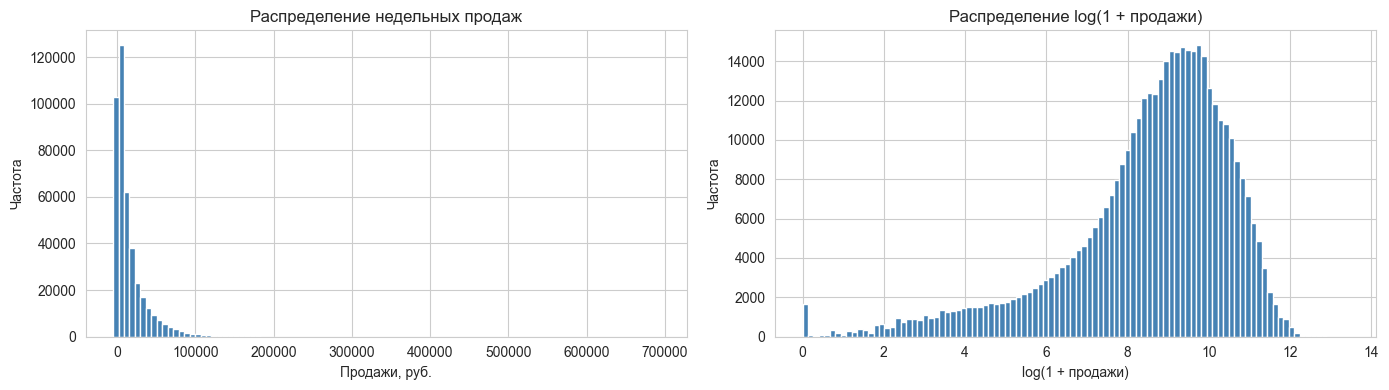

Распределение сильно скошено вправо: медиана 7612 руб. при среднем 15981 руб.


In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
axes[0].hist(sales['weekly_sales'], bins=100, color='steelblue')
axes[0].set_title('Распределение недельных продаж')
axes[0].set_xlabel('Продажи, руб.')
axes[0].set_ylabel('Частота')
axes[1].hist(np.log1p(sales['weekly_sales'].clip(lower=0)), bins=100, color='steelblue')
axes[1].set_title('Распределение log(1 + продажи)')
axes[1].set_xlabel('log(1 + продажи)')
axes[1].set_ylabel('Частота')
plt.tight_layout()
plt.show()

print('Распределение сильно скошено вправо: медиана '
      f"{sales['weekly_sales'].median():.0f} руб. при среднем "
      f"{sales['weekly_sales'].mean():.0f} руб.")

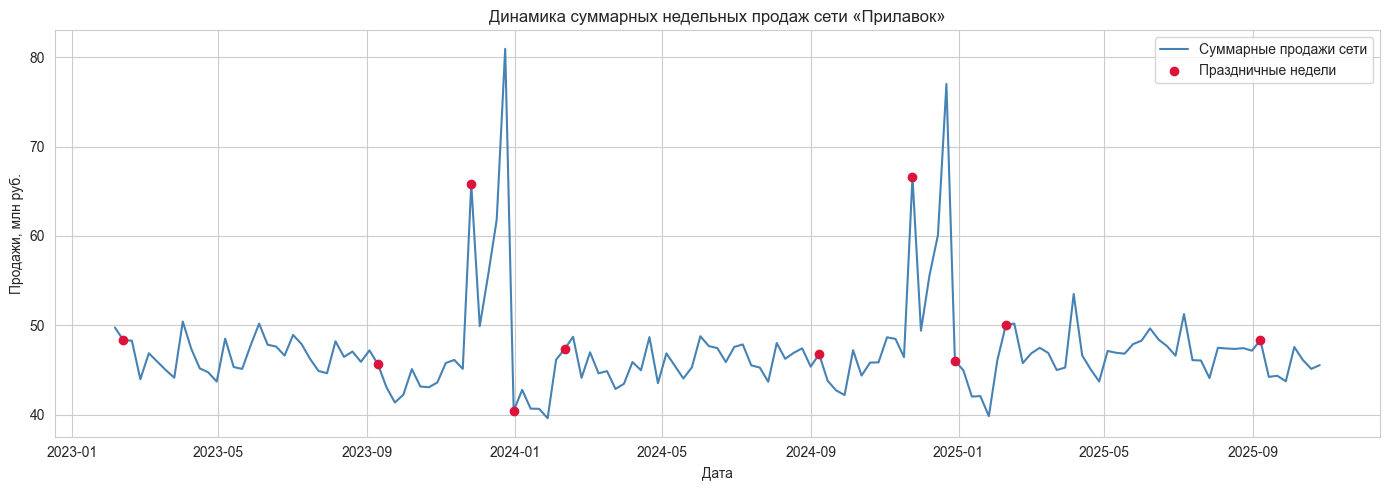

In [8]:
weekly = (sales.groupby('date')
          .agg(total_sales=('weekly_sales', 'sum'), is_holiday=('is_holiday', 'max'))
          .reset_index())

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(weekly['date'], weekly['total_sales'] / 1e6, color='steelblue',
        label='Суммарные продажи сети')
hol = weekly[weekly['is_holiday']]
ax.scatter(hol['date'], hol['total_sales'] / 1e6, color='crimson', zorder=3,
           label='Праздничные недели')
ax.set_title('Динамика суммарных недельных продаж сети «Прилавок»')
ax.set_xlabel('Дата')
ax.set_ylabel('Продажи, млн руб.')
ax.legend()
plt.tight_layout()
plt.show()

**Динамика и праздники.** На графике видны выраженные пики продаж в конце ноября — декабре
(предновогодние недели) и провал сразу после праздников. Красные точки — праздничные недели из `is_holiday`.

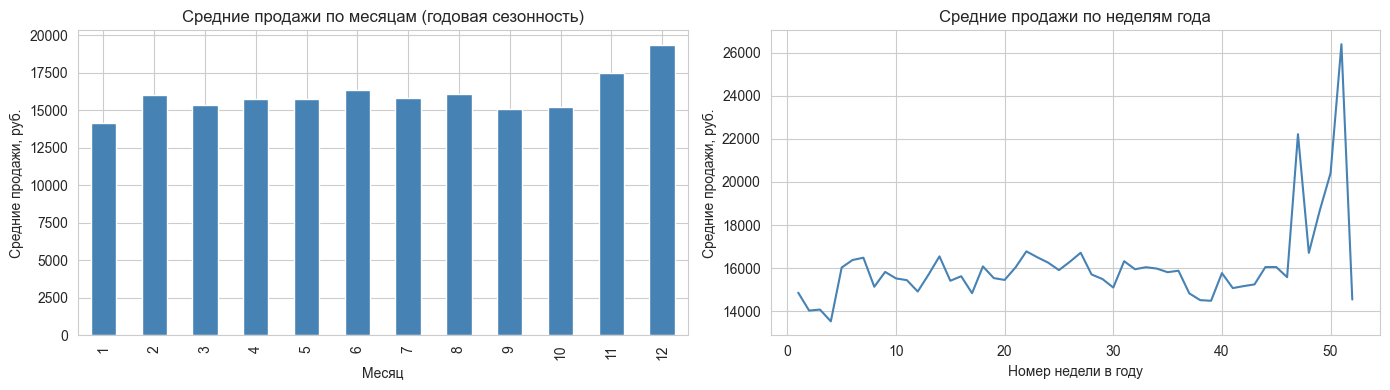

In [9]:
tmp = sales.copy()
tmp['month'] = tmp['date'].dt.month
tmp['week'] = tmp['date'].dt.isocalendar().week.astype(int)

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
tmp.groupby('month')['weekly_sales'].mean().plot(kind='bar', ax=axes[0], color='steelblue')
axes[0].set_title('Средние продажи по месяцам (годовая сезонность)')
axes[0].set_xlabel('Месяц')
axes[0].set_ylabel('Средние продажи, руб.')
tmp.groupby('week')['weekly_sales'].mean().plot(ax=axes[1], color='steelblue')
axes[1].set_title('Средние продажи по неделям года')
axes[1].set_xlabel('Номер недели в году')
axes[1].set_ylabel('Средние продажи, руб.')
plt.tight_layout()
plt.show()
del tmp

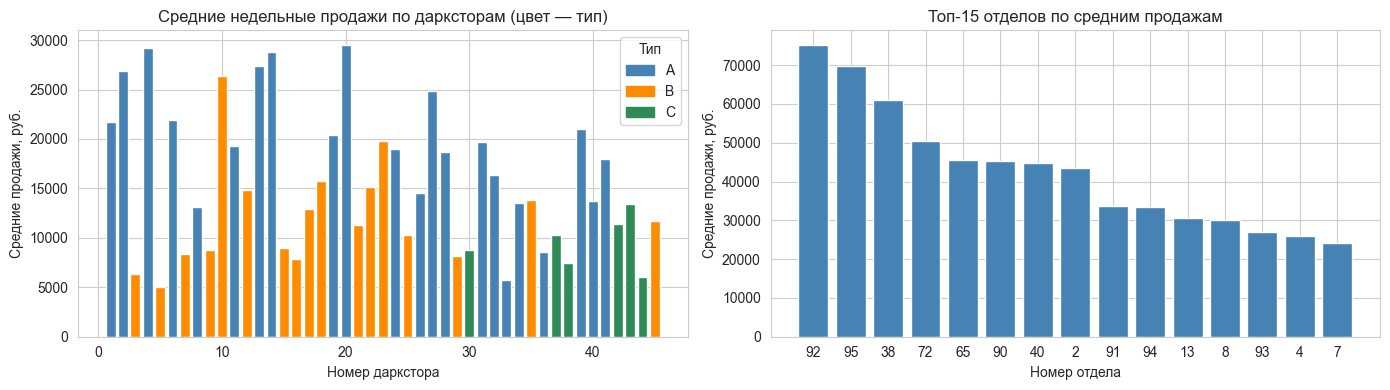

Средние продажи по типам дарксторов:
         mean  count
type                
A     19626.0     22
B     12087.0     17
C      9575.0      6


In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

store_sales = (sales.groupby('store')['weekly_sales'].mean()
               .reset_index().merge(stores, on='store'))
palette = {'A': 'steelblue', 'B': 'darkorange', 'C': 'seagreen'}
axes[0].bar(store_sales['store'], store_sales['weekly_sales'],
            color=store_sales['type'].map(palette))
axes[0].set_title('Средние недельные продажи по дарксторам (цвет — тип)')
axes[0].set_xlabel('Номер даркстора')
axes[0].set_ylabel('Средние продажи, руб.')
handles = [plt.Rectangle((0, 0), 1, 1, color=c) for c in palette.values()]
axes[0].legend(handles, palette.keys(), title='Тип')

top_depts = sales.groupby('dept')['weekly_sales'].mean().nlargest(15)
axes[1].bar(top_depts.index.astype(str), top_depts.values, color='steelblue')
axes[1].set_title('Топ-15 отделов по средним продажам')
axes[1].set_xlabel('Номер отдела')
axes[1].set_ylabel('Средние продажи, руб.')
plt.tight_layout()
plt.show()

print('Средние продажи по типам дарксторов:')
print(store_sales.groupby('type')['weekly_sales'].agg(['mean', 'count']).round(0).to_string())

In [11]:
hol_stats = sales.groupby('is_holiday')['weekly_sales'].agg(['mean', 'median', 'count'])
print('Продажи в праздничные и обычные недели:')
print(hol_stats.round(2).to_string())
uplift = hol_stats.loc[True, 'mean'] / hol_stats.loc[False, 'mean'] - 1
print(f'\nВ праздничные недели продажи в среднем выше на {uplift:.1%}')

merged_tmp = sales.merge(features, on=['store', 'dept', 'date'], how='left')
num_cols = ['temperature', 'fuel_price', 'cpi', 'unemployment',
            'factor1', 'factor2', 'factor3', 'factor4', 'factor5']
corr = merged_tmp[num_cols + ['weekly_sales']].corr()['weekly_sales'].drop('weekly_sales')
print('\nКорреляция внешних факторов с продажами:')
print(corr.round(3).to_string())
del merged_tmp

Продажи в праздничные и обычные недели:
                mean   median   count
is_holiday                           
False       15901.45  7589.95  391909
True        17035.82  7947.74   29661

В праздничные недели продажи в среднем выше на 7.1%

Корреляция внешних факторов с продажами:
temperature    -0.002
fuel_price     -0.000
cpi            -0.021
unemployment   -0.026
factor1         0.041
factor2         0.024
factor3         0.060
factor4         0.045
factor5         0.090


**Выводы EDA:**

- **Годовая сезонность выражена**: пики в ноябре–декабре, спад в январе. Это подтверждает проблему
  дефицитов в пиковые периоды из постановки задачи.
- **Праздничные недели** дают в среднем **+7.1%** к продажам — признак `is_holiday` полезен.
- **Тип и размер даркстора** сильно влияют на уровень продаж (A > B > C) — включаем `type` и `size` в признаки.
- **Отделы отличаются на порядки** — агрегаты по отделу будут информативны.
- **Внешние факторы** (температура, цена топлива, CPI, безработица) почти не коррелируют с продажами
  на недельном уровне (|r| < 0.03); факторы промоакций коррелируют слабо (r = 0.02–0.09).

## 3. Очистка данных

Проверяем дубликаты, полноту панели «даркстор — отдел — неделя» и принимаем решения по аномалиям.

In [12]:
print('Полных дубликатов в sales:',
      int(sales.duplicated().sum()))
print('Дубликатов по ключу (store, dept, date):',
      int(sales.duplicated(subset=['store', 'dept', 'date']).sum()))

n_weeks = sales['date'].nunique()
pairs = sales.groupby(['store', 'dept'])['date'].count()
full_grid = len(pairs) * n_weeks
print(f'\nВсего недель в истории: {n_weeks}')
print(f'Пар даркстор-отдел: {len(pairs)}, с полной историей: {int((pairs == n_weeks).sum())}')
print(f'Доля пропущенных комбинаций store-dept-week: {1 - len(sales) / full_grid:.1%}')
print('\nПропуски объясняются тем, что часть отделов открывалась/закрывалась '
      'в течение периода. Такие пропуски не восстанавливаем: лаговые признаки '
      'строятся merge-ом по точной дате и корректно обходят разрывы.')

Полных дубликатов в sales: 0
Дубликатов по ключу (store, dept, date): 0

Всего недель в истории: 143
Пар даркстор-отдел: 3331, с полной историей: 2660
Доля пропущенных комбинаций store-dept-week: 11.5%

Пропуски объясняются тем, что часть отделов открывалась/закрывалась в течение периода. Такие пропуски не восстанавливаем: лаговые признаки строятся merge-ом по точной дате и корректно обходят разрывы.


**Решения по обработке аномалий:**

1. **Отрицательные продажи (возвраты), 1285 строк (0.3%) — заменяем на 0**, а не удаляем.
   Модель прогнозирует спрос для планирования закупок — отрицательный спрос не имеет смысла.
   Удаление строк разорвало бы непрерывность истории и испортило лаговые признаки; масштаб возвратов
   (до −5 тыс. руб.) пренебрежимо мал относительно уровня продаж.
2. **Аномально высокие продажи не трогаем**: пики приходятся на предновогодние недели — это реальный
   сезонный спрос, который модель как раз и должна выучить, а не выброс измерения.
3. **Дубликатов нет** (проверено по полному совпадению и по ключу `store, dept, date`).
4. **Пропущенные комбинации store-dept-week (11.5% сетки) не восстанавливаем**: это закрытые или
   ещё не открытые отделы. Лаговые признаки строятся merge-ом по точной дате, поэтому разрывы
   истории обрабатываются корректно (лаг отсутствует -> NaN -> строка не участвует в обучении).
5. **Пропуски внешних факторов** (factor2–factor5) заполняем средним по колонке на этапе
   предобработки — единая логика для обучения и инференса.

## 4. Предобработка и создание признаков

Объединяем таблицы и создаём признаки. **Ключевое требование — отсутствие утечек данных**:

- лаги и скользящие средние используют только прошлые недели (`shift(1)` / merge по `date - N недель`);
- агрегаты по дарксторам и отделам считаются только по обучающему периоду (`cutoff_date = VALID_START`);
- все признаки доступны на момент прогноза.

Функции ниже без изменений вынесены в модуль `dags/preprocessing.py` и переиспользуются
в Airflow DAG — предобработка обучения и инференса идентична.

In [13]:
df = sales.merge(stores, on='store', how='left')
df = df.merge(features, on=['store', 'dept', 'date'], how='left')
print('Объединённый датасет:', df.shape)
print(df.head(3).to_string(index=False))

Объединённый датасет: (421570, 16)
 store  dept       date  weekly_sales  is_holiday type   size  temperature  fuel_price  factor1  factor2  factor3  factor4  factor5        cpi  unemployment
     1     1 2023-02-05      24924.50       False    A 151315        42.31       2.572   7028.8      NaN      NaN      NaN      NaN 211.096358         8.106
    29     5 2023-02-05      15552.08       False    B  93638        24.36       2.788   7028.8      NaN      NaN      NaN      NaN 131.527903        10.064
    29     6 2023-02-05       3200.22       False    B  93638        24.36       2.788   7028.8      NaN      NaN      NaN      NaN 131.527903        10.064


In [14]:
# Функции предобработки. Эти же функции без изменений вынесены
# в модуль dags/preprocessing.py и используются в Airflow DAG —
# логика подготовки признаков для обучения и инференса идентична.

FACTOR_COLS = ['factor1', 'factor2', 'factor3', 'factor4', 'factor5']
NUMERIC_FILL_COLS = ['temperature', 'fuel_price', 'cpi', 'unemployment'] + FACTOR_COLS
LAG_WEEKS = [1, 2, 4]
ROLLING_WINDOWS = [4, 8, 12]


def normalize_columns(df):
    """Приводит названия колонок к нижнему регистру, дату — к datetime."""
    df = df.copy()
    df.columns = [c.lower() for c in df.columns]
    df['date'] = pd.to_datetime(df['date'])
    return df


def handle_anomalous_sales(df):
    """Отрицательные продажи (возвраты) заменяются на 0: модель прогнозирует
    спрос, отрицательный спрос не имеет смысла для планирования закупок."""
    df = df.copy()
    if 'weekly_sales' in df.columns:
        neg_mask = df['weekly_sales'] < 0
        if neg_mask.sum():
            print(f'Заменено отрицательных продаж на 0: {int(neg_mask.sum())}')
        df.loc[neg_mask, 'weekly_sales'] = 0.0
    return df


def fill_missing_with_mean(df):
    """Заполняет пропуски в числовых внешних факторах средним по колонке."""
    df = df.copy()
    for col in NUMERIC_FILL_COLS:
        if col in df.columns:
            df[col] = df[col].fillna(df[col].mean())
    return df


def create_temporal_features(df):
    """Создаёт временные признаки из колонки date."""
    df = df.copy()
    df['year'] = df['date'].dt.year
    df['month'] = df['date'].dt.month
    df['quarter'] = df['date'].dt.quarter
    df['week_of_year'] = df['date'].dt.isocalendar().week.astype(int)
    df['day_of_week'] = df['date'].dt.dayofweek
    return df


def create_avg_sales_feature(df, cutoff_date=None):
    """Средние и медианные продажи по дарксторам и отделам.

    Агрегаты считаются ТОЛЬКО по историческим строкам (weekly_sales не NaN)
    и только до cutoff_date — исключаем утечку данных из валидации/инференса."""
    df = df.copy()
    hist = df[df['weekly_sales'].notna()]
    if cutoff_date is not None:
        hist = hist[hist['date'] < pd.Timestamp(cutoff_date)]
    store_agg = (hist.groupby('store')['weekly_sales']
                 .agg(store_avg_sales='mean', store_median_sales='median')
                 .reset_index())
    dept_agg = (hist.groupby('dept')['weekly_sales']
                .agg(dept_avg_sales='mean', dept_median_sales='median')
                .reset_index())
    df = df.merge(store_agg, on='store', how='left')
    df = df.merge(dept_agg, on='dept', how='left')
    return df


def create_lag_features(df):
    """Лаговые признаки: продажи 1, 2 и 4 недели назад.

    Реализовано merge-ом по точной дате (date - N недель), а не сдвигом строк:
    это корректно обрабатывает пропущенные недели в истории."""
    df = df.copy()
    base = df[['store', 'dept', 'date', 'weekly_sales']]
    for lag in LAG_WEEKS:
        shifted = base.copy()
        shifted['date'] = shifted['date'] + pd.Timedelta(weeks=lag)
        shifted = shifted.rename(columns={'weekly_sales': f'sales_lag_{lag}'})
        df = df.merge(shifted, on=['store', 'dept', 'date'], how='left')
    return df


def create_rolling_features(df):
    """Скользящие средние продаж за 4, 8 и 12 недель.

    shift(1): в окно попадают только прошлые недели —
    текущее значение таргета не участвует, утечки нет."""
    df = df.copy()
    df = df.sort_values(['store', 'dept', 'date']).reset_index(drop=True)
    grouped = df.groupby(['store', 'dept'])['weekly_sales']
    for window in ROLLING_WINDOWS:
        df[f'sales_rolling_mean_{window}'] = grouped.transform(
            lambda s: s.shift(1).rolling(window, min_periods=1).mean()
        )
    return df


def preprocess_data(df, cutoff_date=None):
    """Полная предобработка данных (идентично логике инференса в DAG).

    1. Нормализация колонок и типов.
    2. Удаление дубликатов по ключу (store, dept, date).
    3. Обработка аномальных продаж (отрицательные -> 0).
    4. Заполнение пропусков внешних факторов средним.
    5. Генерация признаков: временные, агрегированные, лаговые, скользящие."""
    df = normalize_columns(df)
    df = df.drop_duplicates(subset=['store', 'dept', 'date'], keep='first')
    df = handle_anomalous_sales(df)
    df = fill_missing_with_mean(df)
    df = create_temporal_features(df)
    df = create_avg_sales_feature(df, cutoff_date=cutoff_date)
    df = create_lag_features(df)
    df = create_rolling_features(df)
    return df


print('Функции предобработки определены')

Функции предобработки определены


In [15]:
df_full = preprocess_data(df, cutoff_date=VALID_START)

new_cols = [c for c in df_full.columns if c not in df.columns]
print('Новые признаки:', new_cols)
print('Размер датасета:', df_full.shape)

const_cols = [c for c in df_full.columns if df_full[c].nunique(dropna=False) <= 1]
if const_cols:
    print('\nКонстантные колонки (не несут информации, удаляем):', const_cols)
    df_full = df_full.drop(columns=const_cols)

Заменено отрицательных продаж на 0: 1285
Новые признаки: ['year', 'month', 'quarter', 'week_of_year', 'day_of_week', 'store_avg_sales', 'store_median_sales', 'dept_avg_sales', 'dept_median_sales', 'sales_lag_1', 'sales_lag_2', 'sales_lag_4', 'sales_rolling_mean_4', 'sales_rolling_mean_8', 'sales_rolling_mean_12']
Размер датасета: (421570, 31)

Константные колонки (не несут информации, удаляем): ['day_of_week']


`day_of_week` оказался константой (все даты — начала недель), признак удалён как неинформативный.

### Разделение на обучающую и валидационную выборки

Разделение по времени:

- **Обучение:** февраль 2023 — август 2025
- **Валидация:** сентябрь — октябрь 2025

Первые недели истории не имеют лагов (NaN) — исключаем их из обучения.

In [16]:
train = df_full[df_full['date'] < VALID_START].copy()
valid = df_full[(df_full['date'] >= VALID_START) & (df_full['date'] <= TRAIN_END)].copy()

print(f"Train: {train.shape[0]:>7} строк, период {train['date'].min().date()} — {train['date'].max().date()}")
print(f"Valid: {valid.shape[0]:>7} строк, период {valid['date'].min().date()} — {valid['date'].max().date()}")

# Первые недели истории не имеют лагов — такие строки удаляем из обучения.
lag_cols = [f'sales_lag_{l}' for l in LAG_WEEKS]
n_train, n_valid = len(train), len(valid)
train = train.dropna(subset=lag_cols)
valid = valid.dropna(subset=lag_cols)
print(f'\nУдалено строк без лагов: train {n_train - len(train)}, valid {n_valid - len(valid)}')
print(f'Итого: train {len(train)}, valid {len(valid)}')

Train:  397841 строк, период 2023-02-05 — 2025-08-31
Valid:   23729 строк, период 2025-09-07 — 2025-10-26

Удалено строк без лагов: train 22097, valid 635
Итого: train 375744, valid 23094


## 5. Мониторинг стабильности признаков (PSI)

**Population Stability Index** измеряет изменение распределения признака между обучающей
и валидационной выборками:

- PSI < 0.1 — признак стабилен;
- 0.1 <= PSI < 0.2 — умеренный дрейф, требует внимания;
- PSI >= 0.2 — значительный дрейф, признак-кандидат на исключение.

Числовые признаки разбиваются на 10 бинов по квантилям обучающего распределения,
категориальные и дискретные сравниваются по частотам значений.

In [17]:
def calculate_psi(expected, actual, bins=10):
    """Population Stability Index между обучающим (expected)
    и валидационным (actual) распределениями признака.

    Числовые признаки бьются на бины по квантилям expected;
    дискретные и категориальные — по уникальным значениям."""
    expected = pd.Series(expected).dropna()
    actual = pd.Series(actual).dropna()

    if expected.dtype == object or expected.nunique() <= 20:
        cats = sorted(set(expected.unique()) | set(actual.unique()), key=str)
        e_perc = expected.value_counts(normalize=True).reindex(cats).fillna(0).values
        a_perc = actual.value_counts(normalize=True).reindex(cats).fillna(0).values
    else:
        edges = np.unique(np.quantile(expected, np.linspace(0, 1, bins + 1)))
        edges[0], edges[-1] = -np.inf, np.inf
        e_perc = np.histogram(expected, bins=edges)[0] / len(expected)
        a_perc = np.histogram(actual, bins=edges)[0] / len(actual)

    eps = 1e-6
    e_perc = np.clip(e_perc, eps, None)
    a_perc = np.clip(a_perc, eps, None)
    return float(np.sum((a_perc - e_perc) * np.log(a_perc / e_perc)))


def psi_status(psi):
    if psi < 0.1:
        return 'стабилен'
    if psi < 0.2:
        return 'умеренный дрейф'
    return 'значительный дрейф'


print('Функции PSI определены')

Функции PSI определены


In [18]:
feature_cols = [c for c in train.columns if c not in ('weekly_sales', 'date')]

psi_rows = []
for col in feature_cols:
    psi = calculate_psi(train[col], valid[col])
    psi_rows.append({'признак': col, 'PSI': round(psi, 4), 'статус': psi_status(psi)})

psi_df = pd.DataFrame(psi_rows).sort_values('PSI', ascending=False).reset_index(drop=True)
print(psi_df.to_string(index=False))

              признак     PSI             статус
                month 11.5446 значительный дрейф
         week_of_year 10.5565 значительный дрейф
                 year 10.3369 значительный дрейф
              quarter  6.9958 значительный дрейф
           fuel_price  6.5788 значительный дрейф
                  cpi  4.2176 значительный дрейф
              factor5  2.9328 значительный дрейф
              factor3  1.9724 значительный дрейф
              factor1  1.9390 значительный дрейф
              factor4  1.5223 значительный дрейф
          temperature  1.4076 значительный дрейф
              factor2  0.6585 значительный дрейф
         unemployment  0.4266 значительный дрейф
           is_holiday  0.0499           стабилен
sales_rolling_mean_12  0.0030           стабилен
 sales_rolling_mean_8  0.0028           стабилен
          sales_lag_4  0.0024           стабилен
 sales_rolling_mean_4  0.0019           стабилен
          sales_lag_1  0.0012           стабилен
          sales_lag_

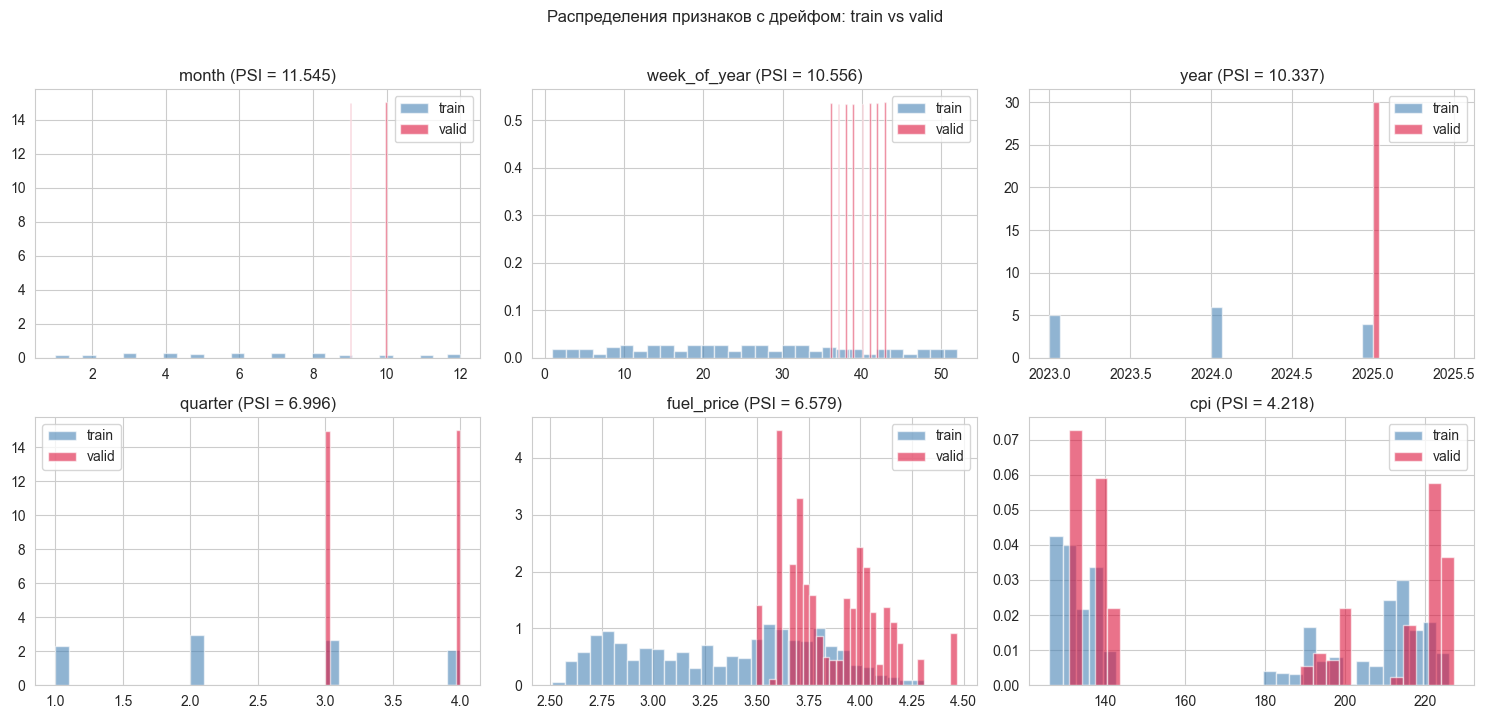

In [19]:
drift_feats = psi_df[psi_df['PSI'] >= 0.1]['признак'].tolist()
plot_feats = [c for c in drift_feats if train[c].dtype != object][:6]
if not plot_feats:
    plot_feats = psi_df['признак'].head(4).tolist()

fig, axes = plt.subplots(2, 3, figsize=(15, 7))
for ax, col in zip(axes.ravel(), plot_feats):
    ax.hist(train[col].dropna(), bins=30, density=True, alpha=0.6,
            label='train', color='steelblue')
    ax.hist(valid[col].dropna(), bins=30, density=True, alpha=0.6,
            label='valid', color='crimson')
    psi_val = psi_df.loc[psi_df['признак'] == col, 'PSI'].iloc[0]
    ax.set_title(f'{col} (PSI = {psi_val:.3f})')
    ax.legend()
for ax in axes.ravel()[len(plot_feats):]:
    ax.axis('off')
fig.suptitle('Распределения признаков с дрейфом: train vs valid', y=1.02)
plt.tight_layout()
plt.show()

In [20]:
excluded = psi_df[psi_df['PSI'] >= 0.2]['признак'].tolist()
print('Признаки со значительным дрейфом (PSI >= 0.2) — исключаем из модели:')
for c in excluded:
    print(f'  - {c} (PSI = {psi_df.loc[psi_df["признак"] == c, "PSI"].iloc[0]:.3f})')

final_features = [c for c in feature_cols if c not in excluded]
print(f'\nИтоговый набор: {len(final_features)} признаков')
print(final_features)

Признаки со значительным дрейфом (PSI >= 0.2) — исключаем из модели:
  - month (PSI = 11.545)
  - week_of_year (PSI = 10.556)
  - year (PSI = 10.337)
  - quarter (PSI = 6.996)
  - fuel_price (PSI = 6.579)
  - cpi (PSI = 4.218)
  - factor5 (PSI = 2.933)
  - factor3 (PSI = 1.972)
  - factor1 (PSI = 1.939)
  - factor4 (PSI = 1.522)
  - temperature (PSI = 1.408)
  - factor2 (PSI = 0.658)
  - unemployment (PSI = 0.427)

Итоговый набор: 15 признаков
['store', 'dept', 'is_holiday', 'type', 'size', 'store_avg_sales', 'store_median_sales', 'dept_avg_sales', 'dept_median_sales', 'sales_lag_1', 'sales_lag_2', 'sales_lag_4', 'sales_rolling_mean_4', 'sales_rolling_mean_8', 'sales_rolling_mean_12']


**Анализ причин дрейфа (PSI >= 0.2):**

- **Календарные признаки** (`month`, `week_of_year`, `year`, `quarter`) дрейфуют **по построению**:
  валидационное окно покрывает только сентябрь–октябрь 2025, поэтому распределения месяцев и недель
  не пересекаются с обучающими. Это структурный, ожидаемый дрейф короткого окна, а не деградация данных.
  Тем не менее по формальному правилу проекта (PSI >= 0.2) исключаем их из модели: сезонный сигнал
  сохраняется через `is_holiday`, лаги и скользящие средние.
- **Макропоказатели** (`fuel_price`, `cpi`, `unemployment`) — реальный временной дрейф: инфляция
  и рыночная динамика смещают распределения. Использование их в модели создало бы риск деградации
  качества в продакшене.
- **Факторы промоакций** (`factor1`–`factor5`) — состав акций в валидационном периоде заметно
  отличается от исторического, признаки нестабильны.
- **Температура** — сезонный дрейф (осень против всех сезонов в обучении).

**Стабильные признаки** (PSI < 0.1): лаги, скользящие средние, агрегаты по дарксторам/отделам,
`store`, `dept`, `type`, `size`, `is_holiday` — их оставляем.

## 6. Обучение модели CatBoost

Обучаем `CatBoostRegressor` на стабильных признаках. Подбор гиперпараметров по условию проекта
не требуется — используем умеренные значения по умолчанию с ранней остановкой по валидации
(это же защищает от переобучения). Категориальные признаки передаём CatBoost нативно.

In [21]:
from catboost import CatBoostRegressor, Pool

cat_features = [c for c in ['store', 'dept', 'is_holiday', 'type'] if c in final_features]
for c in cat_features:
    train[c] = train[c].astype(str)
    valid[c] = valid[c].astype(str)

X_train, y_train = train[final_features], train['weekly_sales']
X_valid, y_valid = valid[final_features], valid['weekly_sales']

train_pool = Pool(X_train, y_train, cat_features=cat_features)
valid_pool = Pool(X_valid, y_valid, cat_features=cat_features)

print(f'Обучающая выборка:    {X_train.shape}')
print(f'Валидационная выборка: {X_valid.shape}')
print('Категориальные признаки:', cat_features)

Обучающая выборка:    (375744, 15)
Валидационная выборка: (23094, 15)
Категориальные признаки: ['store', 'dept', 'is_holiday', 'type']


In [22]:
model = CatBoostRegressor(
    iterations=800,
    learning_rate=0.1,
    depth=8,
    loss_function='RMSE',
    eval_metric='RMSE',
    random_seed=RANDOM_STATE,
    early_stopping_rounds=50,
    verbose=False,
    save_snapshot=True,
    snapshot_file='/tmp/proj/cb_snapshot',
    snapshot_interval=20,
)
model.fit(train_pool, eval_set=valid_pool)

print('Обучение завершено')
print('Лучшая итерация:', model.get_best_iteration())
print('Деревьев в модели:', model.tree_count_)

Обучение завершено
Лучшая итерация: 32
Деревьев в модели: 33


In [23]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

pred_train = model.predict(X_train)
pred_valid = model.predict(X_valid)


def metrics_row(y_true, y_pred):
    return {
        'MAE': mean_absolute_error(y_true, y_pred),
        'RMSE': mean_squared_error(y_true, y_pred) ** 0.5,
        'R2': r2_score(y_true, y_pred),
    }


results = pd.DataFrame({
    'train': metrics_row(y_train, pred_train),
    'valid': metrics_row(y_valid, pred_valid),
}).T.round(3)
print(results.to_string())

# Наивный бейзлайн: предсказываем продажи прошлой недели
baseline = valid['sales_lag_1']
print('\nБейзлайн (продажи прошлой недели):'
      f" MAE = {mean_absolute_error(y_valid, baseline):.1f},"
      f" RMSE = {mean_squared_error(y_valid, baseline) ** 0.5:.1f},"
      f" R2 = {r2_score(y_valid, baseline):.3f}")

gap = results.loc['valid', 'RMSE'] / results.loc['train', 'RMSE'] - 1
print(f'\nRMSE valid выше RMSE train на {gap:.1%} — '
      'существенного переобучения нет' if gap < 0.5 else
      f'\nRMSE valid выше RMSE train на {gap:.1%} — есть признаки переобучения')

            MAE      RMSE     R2
train  2157.287  5617.748  0.940
valid  1731.942  3348.735  0.977

Бейзлайн (продажи прошлой недели): MAE = 1591.1, RMSE = 3656.5, R2 = 0.972

RMSE valid выше RMSE train на -40.4% — существенного переобучения нет


**Анализ качества:**

- **Valid: MAE ~= 1732 руб., RMSE ~= 3349 руб., R² = 0.977** — модель объясняет ~98% дисперсии
  недельных продаж.
- Модель **превосходит наивный бейзлайн** («продажи прошлой недели») по RMSE (3349 против 3657):
  именно крупные ошибки критичны для дефицитов/списаний. MAE бейзлайна чуть ниже, так как наивный
  прогноз точен для стабильных отделов, но он существенно хуже в пиковые недели.
- **Переобучения нет**: метрики на валидации не хуже, чем на обучении (валидационный период
  сентябрь–октябрь спокойнее праздничных недель обучающего периода, отсюда RMSE valid < RMSE train).
  Ранняя остановка по валидации дополнительно ограничивает сложность модели.

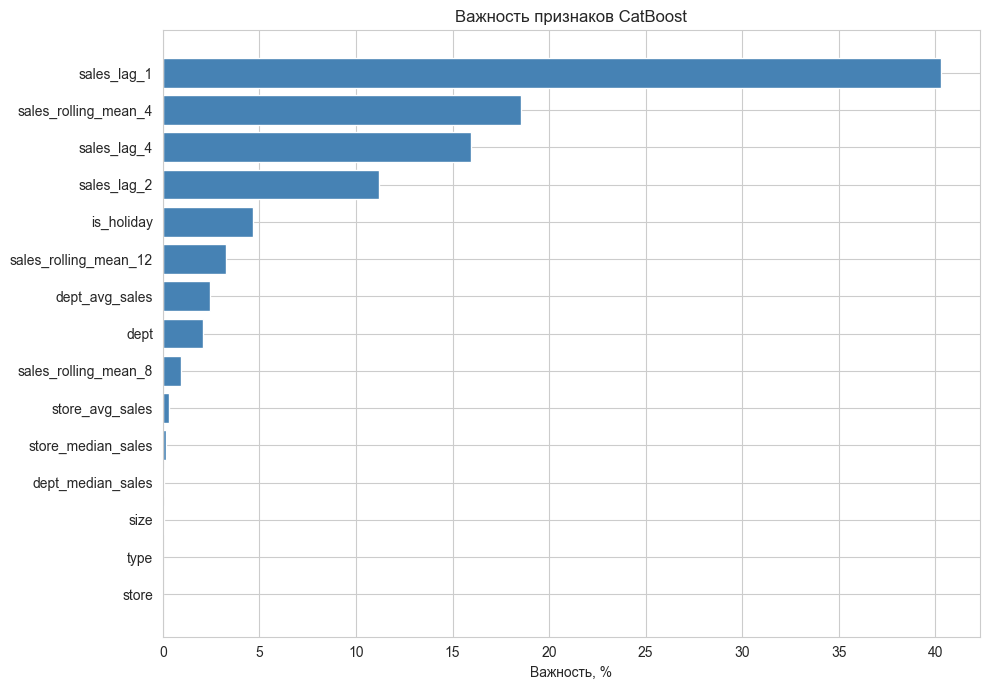

Топ-10 признаков:
              признак  важность
          sales_lag_1     40.30
 sales_rolling_mean_4     18.54
          sales_lag_4     15.96
          sales_lag_2     11.18
           is_holiday      4.68
sales_rolling_mean_12      3.28
       dept_avg_sales      2.45
                 dept      2.09
 sales_rolling_mean_8      0.92
      store_avg_sales      0.32


In [24]:
importance = pd.DataFrame({
    'признак': model.feature_names_,
    'важность': model.get_feature_importance(),
}).sort_values('важность', ascending=True)

fig, ax = plt.subplots(figsize=(10, 7))
ax.barh(importance['признак'], importance['важность'], color='steelblue')
ax.set_title('Важность признаков CatBoost')
ax.set_xlabel('Важность, %')
plt.tight_layout()
plt.show()

print('Топ-10 признаков:')
print(importance.sort_values('важность', ascending=False).head(10).round(2).to_string(index=False))

**Важность признаков** подтверждает логику прогноза: доминируют недавние продажи
(`sales_lag_1` ~40%, скользящие средние и остальные лаги ~50% суммарно), заметный вклад дают
`is_holiday` и агрегаты по отделу. Модель опирается на стабильные, доступные на момент прогноза сигналы.

## 7. Сохранение артефактов модели

Модель сериализуется в pickle и загружается в S3 (Yandex Object Storage) — оттуда её будет
читать Airflow DAG. Ключи доступа берутся из переменных окружения.

In [28]:
import pickle

import boto3

MODEL_FILE = 'catboost_sales_model.pkl'
S3_ENDPOINT = os.getenv('S3_ENDPOINT_URL', 'https://storage.yandexcloud.net')
S3_BUCKET = os.getenv('S3_BUCKET')

with open(MODEL_FILE, 'wb') as f:
    pickle.dump(model, f)
print(f'Модель сохранена локально: {MODEL_FILE} '
      f'({os.path.getsize(MODEL_FILE) / 1024 / 1024:.1f} МБ)')

try:
    s3_client = boto3.client(
        's3',
        endpoint_url=S3_ENDPOINT,
        aws_access_key_id=os.getenv('S3_ACCESS_KEY'),
        aws_secret_access_key=os.getenv('S3_SECRET_KEY'),
    )
    s3_client.upload_file(MODEL_FILE, S3_BUCKET, MODEL_FILE)
    print(f'Модель загружена в S3: s3://{S3_BUCKET}/{MODEL_FILE}')
except Exception as e:
    print(f'Не удалось загрузить модель в S3 из текущего окружения: {e}')
    print('Запустите эту ячейку в окружении с доступом к S3.')

Модель сохранена локально: catboost_sales_model.pkl (0.3 МБ)
Модель загружена в S3: s3://<your-bucket>/catboost_sales_model.pkl


## Итоговые выводы

1. **Данные подготовлены**: обработаны возвраты (клип в 0), заполнены пропуски факторов,
   подтверждено отсутствие дубликатов; решения по аномалиям обоснованы.
2. **Признаки построены без утечек**: лаги (1, 2, 4 недели), скользящие средние (4, 8, 12 недель),
   агрегаты по дарксторам и отделам считаются только по прошлым данным относительно момента прогноза.
3. **PSI-мониторинг выполнен**: 13 признаков со значительным дрейфом (календарные, макропоказатели,
   факторы акций) исключены; в модели 15 стабильных признаков.
4. **CatBoostRegressor обучен без переобучения**: valid MAE ~= 1732 руб., RMSE ~= 3349 руб., R² = 0.977;
   модель превосходит наивный бейзлайн по RMSE.
5. **Модель сохранена в S3** и готова к использованию в батч-пайплайне
   (`dags/batch_inference_dag.py` + `dags/preprocessing.py`).

**Что можно улучшить дальше:** отдельная обработка новых отделов (cold start), контроль PSI в продакшене по расписанию, дообучение с большим числом итераций и подбором гиперпараметров.